# Assignment 4 — Logistic Regression (100% Manual, No Libraries)

**Dataset:** Social Network Ads — 400 users, with `Gender`, `Age`, `EstimatedSalary` as features and `Purchased` (0/1) as the target.

**Goal:** Build a Logistic Regression classifier to predict `Purchased`, then report classification accuracy and Binary Cross-Entropy loss — implemented **completely from scratch using pure Python** (`list`s, `for` loops, built-in `math`/`random`/`csv` modules only). **No `numpy`, `pandas`, or `sklearn.linear_model` anywhere.** `matplotlib` is used only at the end to draw a loss curve.

### Coding Steps (as per assignment brief)
1. Prepare the dataset: read it, convert `Gender` to a numerical representation, drop `User ID` (it's just an identifier).
2. Separate input (`X`) and output (`y`).
3. Split into training (80%) and testing (20%) sets, with a fixed random seed for reproducibility.
4. Train Logistic Regression from scratch using the sigmoid function:
$$\sigma(x) = \frac{1}{1+e^{-x}}, \qquad x = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots$$
5. For each test row, compute the predicted probability and predicted class (threshold = 0.5).
6. Compute classification accuracy:
$$\text{Accuracy} = \frac{\text{number of correct outputs}}{\text{total number of samples}}$$
7. Compute Binary Cross-Entropy loss:
$$L_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\left(Y_i \cdot \log \hat{Y}_i + (1-Y_i)\cdot \log(1-\hat{Y}_i)\right)$$


## 1. Load the Dataset

Two options are given below:

- **Option A (default):** load your own CSV directly from **Google Drive**.
- **Option B (fallback):** use the dataset embedded in this notebook.

Set `USE_DRIVE = True` to use your own Drive file, or `False` to use the embedded fallback data. Either way, we read it with Python's built-in `csv` module — **not** `pandas`.


In [1]:
import csv
import io
import math
import random

USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    csv_path = "/content/drive/My Drive/dataset.csv"

    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
else:
    csv_text = """User ID,Gender,Age,EstimatedSalary,Purchased
15624510,Male,19,19000,0
15810944,Male,35,20000,0
15668575,Female,26,43000,0
15603246,Female,27,57000,0
15804002,Male,19,76000,0
15728773,Male,27,58000,0
15598044,Female,27,84000,0
15694829,Female,32,150000,1
15600575,Male,25,33000,0
15727311,Female,35,65000,0
15570769,Female,26,80000,0
15606274,Female,26,52000,0
15746139,Male,20,86000,0
15704987,Male,32,18000,0
15628972,Male,18,82000,0
15697686,Male,29,80000,0
15733883,Male,47,25000,1
15617482,Male,45,26000,1
15704583,Male,46,28000,1
15621083,Female,48,29000,1
15649487,Male,45,22000,1
15736760,Female,47,49000,1
15714658,Male,48,41000,1
15599081,Female,45,22000,1
15705113,Male,46,23000,1
15631159,Male,47,20000,1
15792818,Male,49,28000,1
15633531,Female,47,30000,1
15744529,Male,29,43000,0
15669656,Male,31,18000,0
15581198,Male,31,74000,0
15729054,Female,27,137000,1
15573452,Female,21,16000,0
15776733,Female,28,44000,0
15724858,Male,27,90000,0
15713144,Male,35,27000,0
15690188,Female,33,28000,0
15689425,Male,30,49000,0
15671766,Female,26,72000,0
15782806,Female,27,31000,0
15764419,Female,27,17000,0
15591915,Female,33,51000,0
15772798,Male,35,108000,0
15792008,Male,30,15000,0
15715541,Female,28,84000,0
15639277,Male,23,20000,0
15798850,Male,25,79000,0
15776348,Female,27,54000,0
15727696,Male,30,135000,1
15793813,Female,31,89000,0
15694395,Female,24,32000,0
15764195,Female,18,44000,0
15744919,Female,29,83000,0
15671655,Female,35,23000,0
15654901,Female,27,58000,0
15649136,Female,24,55000,0
15775562,Female,23,48000,0
15807481,Male,28,79000,0
15642885,Male,22,18000,0
15789109,Female,32,117000,0
15814004,Male,27,20000,0
15673619,Male,25,87000,0
15595135,Female,23,66000,0
15583681,Male,32,120000,1
15605000,Female,59,83000,0
15718071,Male,24,58000,0
15679760,Male,24,19000,0
15654574,Female,23,82000,0
15577178,Female,22,63000,0
15595324,Female,31,68000,0
15756932,Male,25,80000,0
15726358,Female,24,27000,0
15595228,Female,20,23000,0
15782530,Female,33,113000,0
15592877,Male,32,18000,0
15651983,Male,34,112000,1
15746737,Male,18,52000,0
15774179,Female,22,27000,0
15667265,Female,28,87000,0
15655123,Female,26,17000,0
15595917,Male,30,80000,0
15668385,Male,39,42000,0
15709476,Male,20,49000,0
15711218,Male,35,88000,0
15798659,Female,30,62000,0
15663939,Female,31,118000,1
15694946,Male,24,55000,0
15631912,Female,28,85000,0
15768816,Male,26,81000,0
15682268,Male,35,50000,0
15684801,Male,22,81000,0
15636428,Female,30,116000,0
15809823,Male,26,15000,0
15699284,Female,29,28000,0
15786993,Female,29,83000,0
15709441,Female,35,44000,0
15710257,Female,35,25000,0
15582492,Male,28,123000,1
15575694,Male,35,73000,0
15756820,Female,28,37000,0
15766289,Male,27,88000,0
15593014,Male,28,59000,0
15584545,Female,32,86000,0
15675949,Female,33,149000,1
15672091,Female,19,21000,0
15801658,Male,21,72000,0
15706185,Female,26,35000,0
15789863,Male,27,89000,0
15720943,Male,26,86000,0
15697997,Female,38,80000,0
15665416,Female,39,71000,0
15660200,Female,37,71000,0
15619653,Male,38,61000,0
15773447,Male,37,55000,0
15739160,Male,42,80000,0
15689237,Male,40,57000,0
15679297,Male,35,75000,0
15591433,Male,36,52000,0
15642725,Male,40,59000,0
15701962,Male,41,59000,0
15811613,Female,36,75000,0
15741049,Male,37,72000,0
15724423,Female,40,75000,0
15574305,Male,35,53000,0
15678168,Female,41,51000,0
15697020,Female,39,61000,0
15610801,Male,42,65000,0
15745232,Male,26,32000,0
15722758,Male,30,17000,0
15792102,Female,26,84000,0
15675185,Male,31,58000,0
15801247,Male,33,31000,0
15725660,Male,30,87000,0
15638963,Female,21,68000,0
15800061,Female,28,55000,0
15578006,Male,23,63000,0
15668504,Female,20,82000,0
15687491,Male,30,107000,1
15610403,Female,28,59000,0
15741094,Male,19,25000,0
15807909,Male,19,85000,0
15666141,Female,18,68000,0
15617134,Male,35,59000,0
15783029,Male,30,89000,0
15622833,Female,34,25000,0
15746422,Female,24,89000,0
15750839,Female,27,96000,1
15749130,Female,41,30000,0
15779862,Male,29,61000,0
15767871,Male,20,74000,0
15679651,Female,26,15000,0
15576219,Male,41,45000,0
15699247,Male,31,76000,0
15619087,Female,36,50000,0
15605327,Male,40,47000,0
15610140,Female,31,15000,0
15791174,Male,46,59000,0
15602373,Male,29,75000,0
15762605,Male,26,30000,0
15598840,Female,32,135000,1
15744279,Male,32,100000,1
15670619,Male,25,90000,0
15599533,Female,37,33000,0
15757837,Male,35,38000,0
15697574,Female,33,69000,0
15578738,Female,18,86000,0
15762228,Female,22,55000,0
15614827,Female,35,71000,0
15789815,Male,29,148000,1
15579781,Female,29,47000,0
15587013,Male,21,88000,0
15570932,Male,34,115000,0
15794661,Female,26,118000,0
15581654,Female,34,43000,0
15644296,Female,34,72000,0
15614420,Female,23,28000,0
15609653,Female,35,47000,0
15594577,Male,25,22000,0
15584114,Male,24,23000,0
15673367,Female,31,34000,0
15685576,Male,26,16000,0
15774727,Female,31,71000,0
15694288,Female,32,117000,1
15603319,Male,33,43000,0
15759066,Female,33,60000,0
15814816,Male,31,66000,0
15724402,Female,20,82000,0
15571059,Female,33,41000,0
15674206,Male,35,72000,0
15715160,Male,28,32000,0
15730448,Male,24,84000,0
15662067,Female,19,26000,0
15779581,Male,29,43000,0
15662901,Male,19,70000,0
15689751,Male,28,89000,0
15667742,Male,34,43000,0
15738448,Female,30,79000,0
15680243,Female,20,36000,0
15745083,Male,26,80000,0
15708228,Male,35,22000,0
15628523,Male,35,39000,0
15708196,Male,49,74000,0
15735549,Female,39,134000,1
15809347,Female,41,71000,0
15660866,Female,58,101000,1
15766609,Female,47,47000,0
15654230,Female,55,130000,1
15794566,Female,52,114000,0
15800890,Female,40,142000,1
15697424,Female,46,22000,0
15724536,Female,48,96000,1
15735878,Male,52,150000,1
15707596,Female,59,42000,0
15657163,Male,35,58000,0
15622478,Male,47,43000,0
15779529,Female,60,108000,1
15636023,Male,49,65000,0
15582066,Male,40,78000,0
15666675,Female,46,96000,0
15732987,Male,59,143000,1
15789432,Female,41,80000,0
15663161,Male,35,91000,1
15694879,Male,37,144000,1
15593715,Male,60,102000,1
15575002,Female,35,60000,0
15622171,Male,37,53000,0
15795224,Female,36,126000,1
15685346,Male,56,133000,1
15691808,Female,40,72000,0
15721007,Female,42,80000,1
15794253,Female,35,147000,1
15694453,Male,39,42000,0
15813113,Male,40,107000,1
15614187,Male,49,86000,1
15619407,Female,38,112000,0
15646227,Male,46,79000,1
15660541,Male,40,57000,0
15753874,Female,37,80000,0
15617877,Female,46,82000,0
15772073,Female,53,143000,1
15701537,Male,42,149000,1
15736228,Male,38,59000,0
15780572,Female,50,88000,1
15769596,Female,56,104000,1
15586996,Female,41,72000,0
15722061,Female,51,146000,1
15638003,Female,35,50000,0
15775590,Female,57,122000,1
15730688,Male,41,52000,0
15753102,Female,35,97000,1
15810075,Female,44,39000,0
15723373,Male,37,52000,0
15795298,Female,48,134000,1
15584320,Female,37,146000,1
15724161,Female,50,44000,0
15750056,Female,52,90000,1
15609637,Female,41,72000,0
15794493,Male,40,57000,0
15569641,Female,58,95000,1
15815236,Female,45,131000,1
15811177,Female,35,77000,0
15680587,Male,36,144000,1
15672821,Female,55,125000,1
15767681,Female,35,72000,0
15600379,Male,48,90000,1
15801336,Female,42,108000,1
15721592,Male,40,75000,0
15581282,Male,37,74000,0
15746203,Female,47,144000,1
15583137,Male,40,61000,0
15680752,Female,43,133000,0
15688172,Female,59,76000,1
15791373,Male,60,42000,1
15589449,Male,39,106000,1
15692819,Female,57,26000,1
15727467,Male,57,74000,1
15734312,Male,38,71000,0
15764604,Male,49,88000,1
15613014,Female,52,38000,1
15759684,Female,50,36000,1
15609669,Female,59,88000,1
15685536,Male,35,61000,0
15750447,Male,37,70000,1
15663249,Female,52,21000,1
15638646,Male,48,141000,0
15734161,Female,37,93000,1
15631070,Female,37,62000,0
15761950,Female,48,138000,1
15649668,Male,41,79000,0
15713912,Female,37,78000,1
15586757,Male,39,134000,1
15596522,Male,49,89000,1
15625395,Male,55,39000,1
15760570,Male,37,77000,0
15566689,Female,35,57000,0
15725794,Female,36,63000,0
15673539,Male,42,73000,1
15705298,Female,43,112000,1
15675791,Male,45,79000,0
15747043,Male,46,117000,1
15736397,Female,58,38000,1
15678201,Male,48,74000,1
15720745,Female,37,137000,1
15637593,Male,37,79000,1
15598070,Female,40,60000,0
15787550,Male,42,54000,0
15603942,Female,51,134000,0
15733973,Female,47,113000,1
15596761,Male,36,125000,1
15652400,Female,38,50000,0
15717893,Female,42,70000,0
15622585,Male,39,96000,1
15733964,Female,38,50000,0
15753861,Female,49,141000,1
15747097,Female,39,79000,0
15594762,Female,39,75000,1
15667417,Female,54,104000,1
15684861,Male,35,55000,0
15742204,Male,45,32000,1
15623502,Male,36,60000,0
15774872,Female,52,138000,1
15611191,Female,53,82000,1
15674331,Male,41,52000,0
15619465,Female,48,30000,1
15575247,Female,48,131000,1
15695679,Female,41,60000,0
15713463,Male,41,72000,0
15785170,Female,42,75000,0
15796351,Male,36,118000,1
15639576,Female,47,107000,1
15693264,Male,38,51000,0
15589715,Female,48,119000,1
15769902,Male,42,65000,0
15587177,Male,40,65000,0
15814553,Male,57,60000,1
15601550,Female,36,54000,0
15664907,Male,58,144000,1
15612465,Male,35,79000,0
15810800,Female,38,55000,0
15665760,Male,39,122000,1
15588080,Female,53,104000,1
15776844,Male,35,75000,0
15717560,Female,38,65000,0
15629739,Female,47,51000,1
15729908,Male,47,105000,1
15716781,Female,41,63000,0
15646936,Male,53,72000,1
15768151,Female,54,108000,1
15579212,Male,39,77000,0
15721835,Male,38,61000,0
15800515,Female,38,113000,1
15591279,Male,37,75000,0
15587419,Female,42,90000,1
15750335,Female,37,57000,0
15699619,Male,36,99000,1
15606472,Male,60,34000,1
15778368,Male,54,70000,1
15671387,Female,41,72000,0
15573926,Male,40,71000,1
15709183,Male,42,54000,0
15577514,Male,43,129000,1
15778830,Female,53,34000,1
15768072,Female,47,50000,1
15768293,Female,42,79000,0
15654456,Male,42,104000,1
15807525,Female,59,29000,1
15574372,Female,58,47000,1
15671249,Male,46,88000,1
15779744,Male,38,71000,0
15624755,Female,54,26000,1
15611430,Female,60,46000,1
15774744,Male,60,83000,1
15629885,Female,39,73000,0
15708791,Male,59,130000,1
15793890,Female,37,80000,0
15646091,Female,46,32000,1
15596984,Female,46,74000,0
15800215,Female,42,53000,0
15577806,Male,41,87000,1
15749381,Female,58,23000,1
15683758,Male,42,64000,0
15670615,Male,48,33000,1
15715622,Female,44,139000,1
15707634,Male,49,28000,1
15806901,Female,57,33000,1
15775335,Male,56,60000,1
15724150,Female,49,39000,1
15627220,Male,39,71000,0
15672330,Male,47,34000,1
15668521,Female,48,35000,1
15807837,Male,48,33000,1
15592570,Male,47,23000,1
15748589,Female,45,45000,1
15635893,Male,60,42000,1
15757632,Female,39,59000,0
15691863,Female,46,41000,1
15706071,Male,51,23000,1
15654296,Female,50,20000,1
15755018,Male,36,33000,0
15594041,Female,49,36000,1"""
    reader = csv.DictReader(io.StringIO(csv_text))
    rows = list(reader)

print("Number of users:", len(rows))
print("Columns:", list(rows[0].keys()))
print("First row:", rows[0])

Number of users: 400
Columns: ['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']
First row: {'User ID': '15624510', 'Gender': 'Male', 'Age': '19', 'EstimatedSalary': '19000', 'Purchased': '0'}


## 2. Prepare the Dataset — Encode `Gender`, Drop `User ID`

`User ID` is only an identifier, so it is not used as an input feature. `Gender` is converted to a numerical representation (`Male` = 1, `Female` = 0), by hand.


In [2]:
feature_names = ['Gender', 'Age', 'EstimatedSalary']

raw_data = []
labels = []
for row in rows:
    gender_numeric = 1.0 if row['Gender'].strip().lower() == 'male' else 0.0
    age = float(row['Age'])
    salary = float(row['EstimatedSalary'])
    raw_data.append([gender_numeric, age, salary])
    labels.append(int(float(row['Purchased'])))

print("Total samples:", len(raw_data))
print("Example features [Gender, Age, EstimatedSalary]:", raw_data[0])
print("Example label:", labels[0])
print("Class distribution -> Purchased=1:", labels.count(1), " Purchased=0:", labels.count(0))

Total samples: 400
Example features [Gender, Age, EstimatedSalary]: [1.0, 19.0, 19000.0]
Example label: 0
Class distribution -> Purchased=1: 143  Purchased=0: 257


## 3. Separate Input (X) and Output (y), then Standardize

$$X = \text{input features}, \qquad y = \text{target variable}$$

`Age` and `EstimatedSalary` are on very different scales, so we standardize all features manually (z-score) before training — this helps gradient descent converge.


In [3]:
X = raw_data
y = labels

def column(data, index):
    return [point[index] for point in data]

def mean(values):
    return sum(values) / len(values)

def std_dev(values, mu):
    variance = sum((v - mu) ** 2 for v in values) / len(values)
    return math.sqrt(variance)

def standardize(data, n_features):
    means = []
    stds = []
    for j in range(n_features):
        col = column(data, j)
        mu = mean(col)
        sigma = std_dev(col, mu)
        means.append(mu)
        stds.append(sigma if sigma > 0 else 1.0)

    standardized = []
    for point in data:
        standardized.append([(point[j] - means[j]) / stds[j] for j in range(n_features)])

    return standardized, means, stds

X_std, feat_means, feat_stds = standardize(X, len(feature_names))

print("Feature means:", [round(m, 3) for m in feat_means])
print("Feature stds :", [round(s, 3) for s in feat_stds])

Feature means: [0.49, 37.655, 69742.5]
Feature stds : [0.5, 10.47, 34054.312]


## 4. Manual Train/Test Split (80% / 20%, fixed random seed)


In [4]:
def train_test_split_manual(data, labels, test_ratio=0.2, seed=42):
    n = len(data)
    indices = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(indices)

    n_test = int(n * test_ratio)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train = [data[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    X_test = [data[i] for i in test_idx]
    y_test = [labels[i] for i in test_idx]

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = train_test_split_manual(X_std, y, test_ratio=0.2, seed=42)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 320
Testing samples : 80


## 5. Manual Logistic Regression (Sigmoid + Gradient Descent)

The sigmoid function and the linear combination $x = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots$ are computed with plain Python. The model is trained with batch gradient descent on the Binary Cross-Entropy loss, all hand-written — no `sklearn.linear_model.LogisticRegression`.


In [5]:
def sigmoid(x):
    if x >= 0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)

def linear_combination(features, betas):
    x = betas[0]
    for j in range(len(features)):
        x += betas[j + 1] * features[j]
    return x

def predict_probability(features, betas):
    x = linear_combination(features, betas)
    return sigmoid(x)

def train_logistic_regression(X_train, y_train, n_features, learning_rate=0.1, n_iterations=2000, seed=42):
    rng = random.Random(seed)
    betas = [0.0] * (n_features + 1)
    n = len(X_train)

    for iteration in range(n_iterations):
        gradients = [0.0] * (n_features + 1)

        for i in range(n):
            y_hat = predict_probability(X_train[i], betas)
            error = y_hat - y_train[i]

            gradients[0] += error
            for j in range(n_features):
                gradients[j + 1] += error * X_train[i][j]

        for j in range(n_features + 1):
            betas[j] -= learning_rate * (gradients[j] / n)

    return betas

n_features = len(feature_names)
betas = train_logistic_regression(X_train, y_train, n_features, learning_rate=0.5, n_iterations=3000, seed=42)

print("Trained coefficients:")
print("  beta_0 (intercept):", betas[0])
for name, b in zip(feature_names, betas[1:]):
    print(f"  beta ({name}):", b)

Trained coefficients:
  beta_0 (intercept): -1.1701679667015554
  beta (Gender): 0.2517167979820993
  beta (Age): 2.7309624184438834
  beta (EstimatedSalary): 1.175884953371912


## 6. Make Predictions on the Test Set (threshold = 0.5)


In [6]:
predicted_probs = []
predicted_classes = []

for features in X_test:
    prob = predict_probability(features, betas)
    predicted_probs.append(prob)
    predicted_classes.append(1 if prob >= 0.5 else 0)

print("Sample predictions vs actual:")
for i in range(10):
    print(f"  prob={predicted_probs[i]:.4f}  predicted_class={predicted_classes[i]}  actual={y_test[i]}")

Sample predictions vs actual:
  prob=0.2372  predicted_class=0  actual=1
  prob=0.0385  predicted_class=0  actual=0
  prob=0.0048  predicted_class=0  actual=0
  prob=0.0656  predicted_class=0  actual=0
  prob=0.0578  predicted_class=0  actual=0
  prob=0.3258  predicted_class=0  actual=0
  prob=0.0183  predicted_class=0  actual=0
  prob=0.3489  predicted_class=0  actual=0
  prob=0.3226  predicted_class=0  actual=0
  prob=0.9275  predicted_class=1  actual=1


## 7. Compute Classification Accuracy

$$\text{Accuracy} = \frac{\text{number of correct outputs}}{\text{total number of samples}}$$


In [7]:
def accuracy_score_manual(y_true, y_pred):
    correct = sum(1 for actual, predicted in zip(y_true, y_pred) if actual == predicted)
    return correct / len(y_true)

accuracy = accuracy_score_manual(y_test, predicted_classes)
print(f"Classification Accuracy = {accuracy:.4f}  ({accuracy*100:.2f}%)")

Classification Accuracy = 0.8625  (86.25%)


## 8. Compute Binary Cross-Entropy Loss

$$L_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\left(Y_i \cdot \log \hat{Y}_i + (1-Y_i)\cdot \log(1-\hat{Y}_i)\right)$$


In [8]:
def binary_cross_entropy_manual(y_true, y_pred_probs, epsilon=1e-15):
    n = len(y_true)
    total_loss = 0.0

    for i in range(n):
        p = min(max(y_pred_probs[i], epsilon), 1 - epsilon)
        total_loss += y_true[i] * math.log(p) + (1 - y_true[i]) * math.log(1 - p)

    return -total_loss / n

bce_loss = binary_cross_entropy_manual(y_test, predicted_probs)
print(f"Binary Cross-Entropy Loss = {bce_loss:.4f}")

Binary Cross-Entropy Loss = 0.3841


## 9. Confusion Matrix (extra check)

A simple manually-built confusion matrix for a fuller picture of model performance.


In [9]:
def confusion_matrix_manual(y_true, y_pred):
    tp = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 1)
    tn = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 0)
    fp = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 1)
    fn = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 0)
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion_matrix_manual(y_test, predicted_classes)

print("Confusion Matrix:")
print(f"                  Predicted 0   Predicted 1")
print(f"  Actual 0  |     {tn:>10}   {fp:>10}")
print(f"  Actual 1  |     {fn:>10}   {tp:>10}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Confusion Matrix:
                  Predicted 0   Predicted 1
  Actual 0  |             53            4
  Actual 1  |              7           16

Precision: 0.8000
Recall   : 0.6957
F1 Score : 0.7442


## 10. Visualizing the Training Loss Curve

`matplotlib` is used **only to draw the chart** — the loss values plotted here were computed by re-running manual gradient descent while recording the loss at each step.


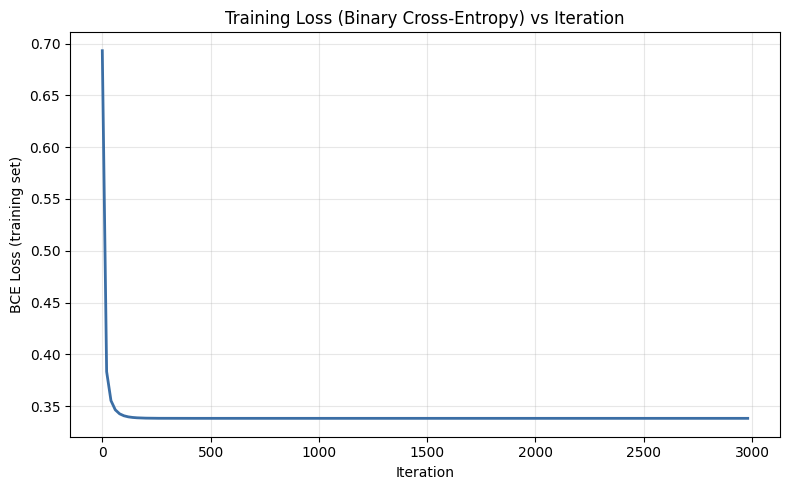

Final test accuracy       : 0.8625
Final test BCE loss       : 0.3841


In [10]:
def train_logistic_regression_with_history(X_train, y_train, n_features, learning_rate=0.1, n_iterations=2000):
    betas = [0.0] * (n_features + 1)
    n = len(X_train)
    loss_history = []

    for iteration in range(n_iterations):
        gradients = [0.0] * (n_features + 1)
        probs = []

        for i in range(n):
            y_hat = predict_probability(X_train[i], betas)
            probs.append(y_hat)
            error = y_hat - y_train[i]
            gradients[0] += error
            for j in range(n_features):
                gradients[j + 1] += error * X_train[i][j]

        for j in range(n_features + 1):
            betas[j] -= learning_rate * (gradients[j] / n)

        if iteration % 20 == 0:
            loss = binary_cross_entropy_manual(y_train, probs)
            loss_history.append((iteration, loss))

    return betas, loss_history

_, loss_history = train_logistic_regression_with_history(X_train, y_train, n_features, learning_rate=0.5, n_iterations=3000)

import matplotlib.pyplot as plt

iterations = [h[0] for h in loss_history]
losses = [h[1] for h in loss_history]

plt.figure(figsize=(8, 5))
plt.plot(iterations, losses, color='#3b6ea5', linewidth=2)
plt.title('Training Loss (Binary Cross-Entropy) vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('BCE Loss (training set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final test accuracy       : {accuracy:.4f}")
print(f"Final test BCE loss       : {bce_loss:.4f}")

## 11. Conclusion

- `Gender` was manually encoded to numeric (Male=1, Female=0), and `User ID` was excluded as it is only an identifier.
- Features were standardized and split into an 80/20 train/test set with a fixed random seed for reproducibility.
- Logistic Regression was trained **entirely from scratch** — the sigmoid function, the linear combination $\beta_0+\beta_1x_1+\dots$, and batch gradient descent on the Binary Cross-Entropy loss were all implemented using **plain Python `list`s and `for` loops only**. **No `numpy`, `pandas`, or `sklearn`** was used anywhere in the modeling.
- Predictions were made on the test set with a 0.5 probability threshold.
- **Classification Accuracy** and **Binary Cross-Entropy Loss** were computed with hand-written functions, matching the formulas given in the assignment.
- `matplotlib` was used only to plot the training loss curve — it played no role in the algorithm itself.
